# Cosimita: source placement gallery (long-running)

Notebook 03 introduces `NearPointSource` and `ExtendedSource` and checks their
normalization. This one asks a different question: **what does the data
actually look like** as you move a near source around the instrument, or widen
an extended source on the sky?

Every panel below is a real simulation run to a few hundred triggered events,
so this notebook takes a few minutes. That is why it lives in `slow/` and is
**not executed by CI** -- the `notebooks` job globs
`docs/examples/cosimita/*.ipynb`, which deliberately does not recurse into
this directory. Notebooks 00-03 stay fast enough to gate every push; this one
is for reading, and for re-running by hand when the physics changes.

Same detector as the rest of the cosimita series: **COMPTELito**, tracker on
top (layer 0 at `y = 300 cm`) and calorimeter below (`y = 0..9 cm`). That
layout matters enormously here, as Section 1 shows.

In [1]:
from gammaraytoys import ToyTracker2D
from gammaraytoys.coordinates import Cartesian2D
from gammaraytoys.sims import (NearPointSource, ExtendedSource, MonoenergeticSpectrum,
                               SimpleTraditionalReconstructor, Earth, SpacecraftInterval)
from histpy import Histogram, Axis
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

comptelito = ToyTracker2D(material = 'Ge',
                          layer_length = 10*u.m,
                          layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                          layer_thickness = 1*u.cm,
                          energy_resolution = 0.03,
                          energy_threshold = 20*u.keV)

reco = SimpleTraditionalReconstructor()
centre = comptelito.surrounding_circle_center
radius = comptelito.surrounding_circle_radius

phi_axis = Axis(np.linspace(0, 180, 45)*u.deg, label = 'Phi')
psi_axis = Axis(np.linspace(-180, 180, 60)*u.deg, label = 'Psi')

def collect(source, n_target = 200, max_launches = 150000, seed = 1, pose = None, earth = None):
    """Simulate until `n_target` triggers, or `max_launches` photons, whichever first.

    The cap bounds the runtime: the worst placement below triggers on 0.17% of
    what it launches, so an uncapped loop would be unpredictable. Returns the
    triggered reconstructions and the number of photons launched to get them.
    """
    np.random.seed(seed)
    events, launched = [], 0
    while len(events) < n_target and launched < max_launches:
        launched += 1
        photon = source.random_photon(comptelito, pose, earth)
        if photon is None:
            continue
        reco_event = reco.reconstruct(comptelito.simulate_event(photon))
        if reco_event.triggered:
            events.append(reco_event)
    return events, launched

def plot_energy_and_cds(ax_energy, ax_cds, events, title, energy_range = (0, 1.2)):
    """Measured energy spectrum and Compton Data Space for one set of events.

    CDS follows tutorial 02's convention: Psi on x, Phi on y.
    """
    ax_energy.hist(u.Quantity([e.energy for e in events]).to_value(u.MeV),
                   bins = 40, range = energy_range, color = 'tab:blue')
    ax_energy.set_xlabel('measured energy [MeV]')
    ax_energy.set_ylabel('triggers / bin')
    ax_energy.set_title(f'{title} -- energy', fontsize = 10)

    h = Histogram([psi_axis, phi_axis])
    h.fill(u.Quantity([e.psi for e in events]).to(u.deg),
           u.Quantity([e.phi for e in events]).to(u.deg),
           warn_overflow = False)
    h.plot(ax_cds)
    ax_cds.set_title(f'{title} -- CDS', fontsize = 10)

## 1. Where a near source sits, and what it does to the data

Six placements: offsets of `d * [0, 1]` (straight above the instrument),
`d * [1, 0]` (straight to the side) and `d * [1, 1]` (diagonally above and to
the side), each at `d = 1a` and `d = 10a`, measured from the surrounding
circle's centre.

Read `d * [1, 1]` literally: the offset is `(d, d)`, so its distance from the
centre is `d * sqrt(2)`, not `d`. The two axis-aligned cases have `s = d`
exactly -- which puts `d = 1a` precisely on the circle, the discontinuity of
Section 1 in notebook 03, where the acceptance is exactly `1/2`.

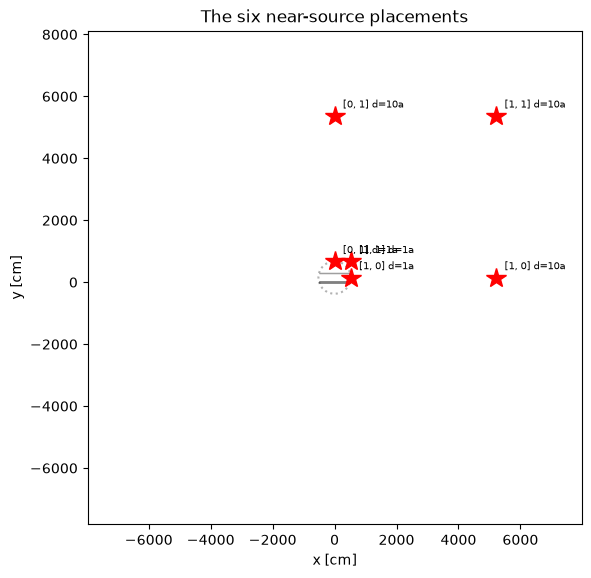

In [2]:
placements = [('[0, 1]', (0.0, 1.0)),
              ('[1, 0]', (1.0, 0.0)),
              ('[1, 1]', (1.0, 1.0))]
distances = [1.0, 10.0]

def near_source(unit, d, rate = 1000/u.s):
    """A NearPointSource offset by `d * unit * a` from the surrounding-circle centre."""
    return NearPointSource(position = Cartesian2D(centre.x + d*unit[0]*radius,
                                                  centre.y + d*unit[1]*radius),
                           spectrum = MonoenergeticSpectrum(1*u.MeV),
                           rate = rate)

fig, ax = plt.subplots(figsize = (6, 6))
comptelito.plot(ax = ax, draw_surrounding_circle = True)
for name, unit in placements:
    for d in distances:
        near_source(unit, d).plot(ax, comptelito)
        ax.annotate(f'{name} d={d:.0f}a',
                    xy = ((centre.x + d*unit[0]*radius).to_value(u.cm),
                          (centre.y + d*unit[1]*radius).to_value(u.cm)),
                    xytext = (6, 6), textcoords = 'offset points', fontsize = 7)
ax.set_title('The six near-source placements')
fig.tight_layout()

In [3]:
# The long one: six independent simulations. A few minutes.
results = {}

for name, unit in placements:
    for d in distances:
        source = near_source(unit, d)
        events, launched = collect(source)
        acceptance = (source.simulated_rate(comptelito)/(1000/u.s)).to_value(u.dimensionless_unscaled)
        results[(name, d)] = dict(events = events, launched = launched,
                                  acceptance = acceptance,
                                  distance = np.hypot(d*unit[0], d*unit[1]))
        print(f"  {name} d={d:4.0f}a  s={results[(name,d)]['distance']:5.2f}a  "
              f"f={acceptance:.4f}  {len(events):3d} triggers from {launched} launched "
              f"({100*len(events)/launched:5.2f}%)")

  [0, 1] d=   1a  s= 1.00a  f=0.5000  200 triggers from 3219 launched ( 6.21%)


  [0, 1] d=  10a  s=10.00a  f=0.0319  200 triggers from 2134 launched ( 9.37%)


  [1, 0] d=   1a  s= 1.00a  f=0.5000  200 triggers from 11660 launched ( 1.72%)


  [1, 0] d=  10a  s=10.00a  f=0.0319  200 triggers from 34752 launched ( 0.58%)


  [1, 1] d=   1a  s= 1.41a  f=0.2500  200 triggers from 2308 launched ( 8.67%)


  [1, 1] d=  10a  s=14.14a  f=0.0225  200 triggers from 3046 launched ( 6.57%)


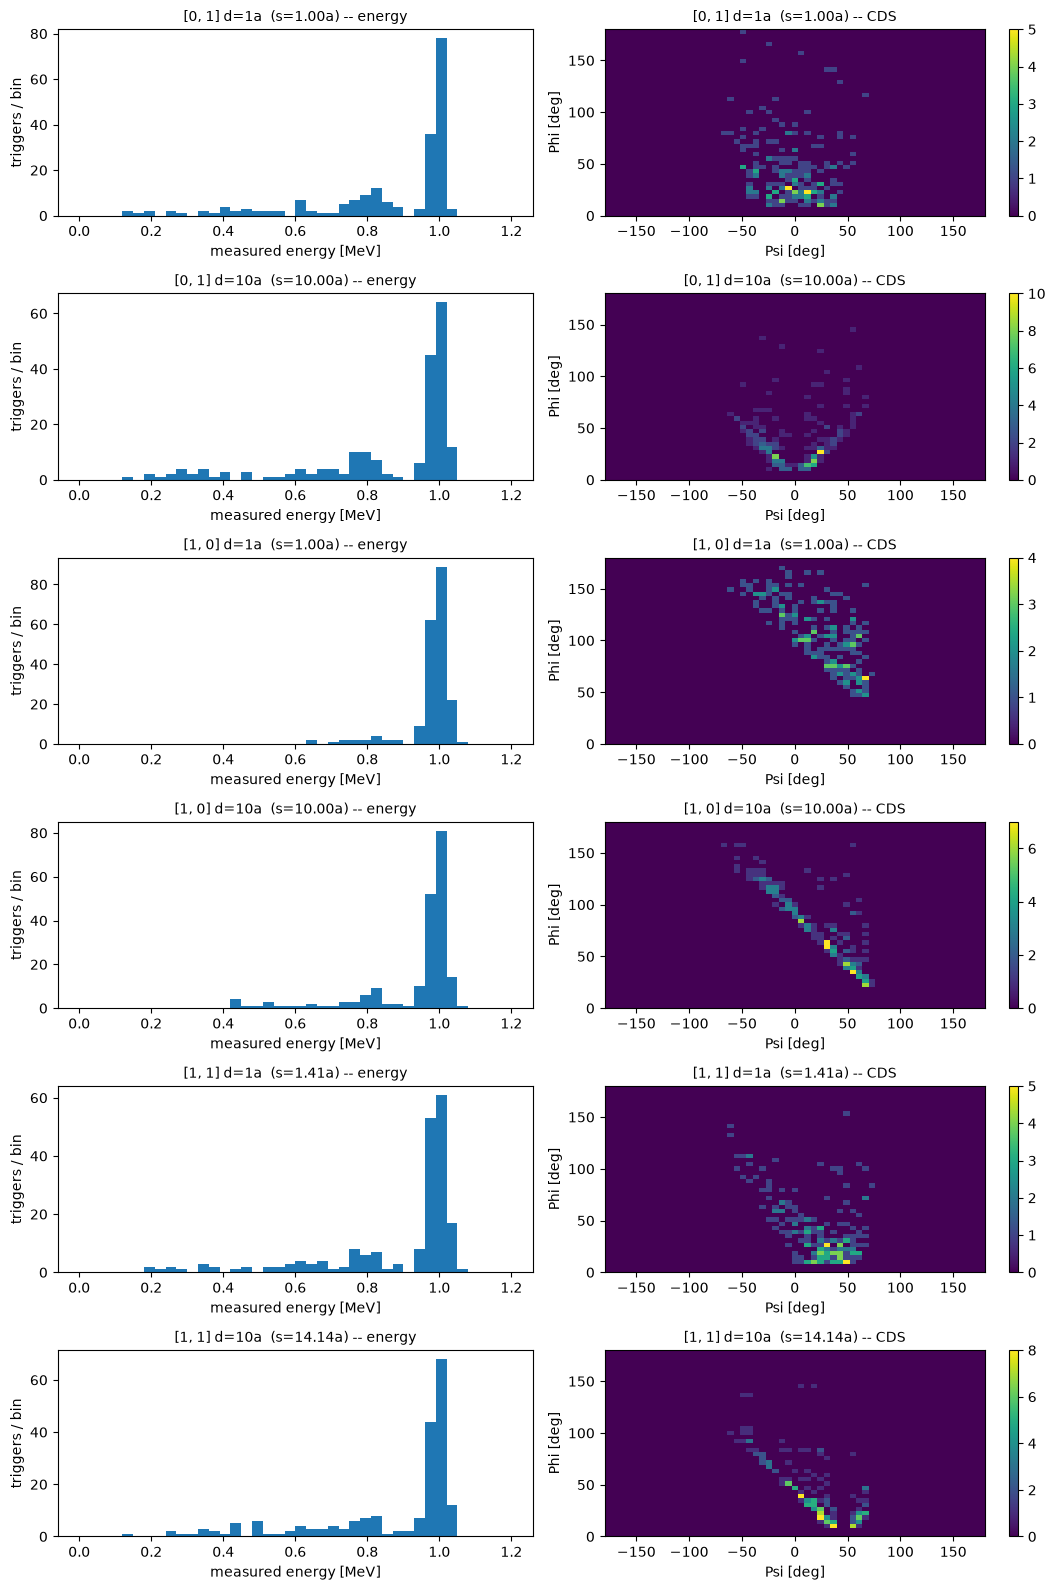

In [4]:
fig, ax = plt.subplots(figsize = (11, 16), nrows = 6, ncols = 2)

for row, ((name, d), result) in enumerate(results.items()):
    plot_energy_and_cds(ax[row][0], ax[row][1], result['events'],
                        f"{name} d={d:.0f}a  (s={result['distance']:.2f}a)")

fig.tight_layout()

### The acceptance is direction-blind. The detector is not.

Compare the two `d = 10a` cases. Both sit exactly `10a` from the centre, so
both have the *same* geometric acceptance `f = arcsin(1/10)/pi = 0.0319` --
`simulated_rate` cannot tell them apart, because it only knows `s`.

But one is above the instrument and one is beside it, and COMPTELito's
`SimpleTraditionalReconstructor` requires the first hit in layer 0, the tracker
plane on top, with a calorimeter below it. A source overhead sends photons down
through exactly that stack. A source to the side sends them grazing across it.

In [5]:
print(f"{'placement':>12} {'s/a':>7} {'acceptance f':>13} {'trigger frac':>13} {'triggers/s at 1 kHz':>21}")
for (name, d), result in results.items():
    trig_frac = len(result['events'])/result['launched']
    print(f"{name+' d='+str(int(d))+'a':>12} {result['distance']:7.2f} {result['acceptance']:13.4f} "
          f"{trig_frac*100:12.2f}% {1000*result['acceptance']*trig_frac:21.2f}")

above = results[('[0, 1]', 10.0)]
beside = results[('[1, 0]', 10.0)]
ratio = ((len(above['events'])/above['launched'])
         / (len(beside['events'])/beside['launched']))
print(f"\nSame acceptance ({above['acceptance']:.4f} both), but the overhead source triggers "
      f"{ratio:.0f}x more often than the one beside it.")

   placement     s/a  acceptance f  trigger frac   triggers/s at 1 kHz
 [0, 1] d=1a    1.00        0.5000         6.21%                 31.07
[0, 1] d=10a   10.00        0.0319         9.37%                  2.99
 [1, 0] d=1a    1.00        0.5000         1.72%                  8.58
[1, 0] d=10a   10.00        0.0319         0.58%                  0.18
 [1, 1] d=1a    1.41        0.2500         8.67%                 21.66
[1, 1] d=10a   14.14        0.0225         6.57%                  1.48

Same acceptance (0.0319 both), but the overhead source triggers 16x more often than the one beside it.


That factor is not a bug and not a normalization error -- it is the
instrument's directional acceptance, the same effect the plan's Section 8
trap 9 warns about for far-field sources. It means **the position of a
background component matters as much as its activity**, and that a background
model built from `simulated_rate` alone, without folding in where the source
sits relative to the detector's own asymmetry, will be wrong by orders of
magnitude.

The measured energy spectra, by contrast, barely move: all six are dominated
by the 1 MeV line, with medians of 0.98-0.99 MeV. Placement changes *how many*
photons trigger and *what directions* they arrive from, not how much energy a
triggering photon deposits. The overhead placements do carry a slightly larger
low-energy tail (12% of `[0, 1]` triggers land below 0.5 MeV against 3% of
`[1, 0]`'s), which is worth noticing but is a small effect next to the factor
in the rate.

## 2. What `width` does to an extended source's data

Three regimes of the same `ExtendedSource`, at one flux and one sky angle:
the **narrow limit** (`0.01 deg`, effectively a point source), an
**intermediate** width (`20 deg`), and the **wide limit** (`720 deg`, which is
`kappa = 0.006` and indistinguishable from an isotropic sky -- see notebook 03
for why 180 deg is not wide enough).

All three are run at a very high orbit so that the Earth occults essentially
nothing, which means the three panels differ **only** in `width`. At a real
altitude the Earth would carve a ~140 deg wedge out of the wide case and the
comparison would confound two effects at once.

In [6]:
earth = Earth()
far_pose = SpacecraftInterval(start_time = 0*u.s, stop_time = 1*u.s, livetime = 1*u.s,
                              attitude = 90*u.deg, orbit_angle = 90*u.deg,
                              orbit_radius = 4_000_000*u.km)

widths = [0.01, 20.0, 720.0]*u.deg
extended_results = {}

for width in widths:
    source = ExtendedSource(sky_angle = 40*u.deg, width = width,
                            spectrum = MonoenergeticSpectrum(1*u.MeV),
                            flux = 1e-3/u.cm/u.s)
    events, launched = collect(source, pose = far_pose, earth = earth)
    extended_results[width] = dict(events = events, launched = launched)
    print(f"  width = {width:8.2f}  {len(events):3d} triggers from {launched} launched "
          f"({100*len(events)/launched:5.2f}%),  "
          f"simulated_rate = {source.simulated_rate(comptelito).to(1/u.s):.4f}")

  width =     0.01 deg  200 triggers from 2899 launched ( 6.90%),  simulated_rate = 1.0440 1 / s


  width =    20.00 deg  200 triggers from 3045 launched ( 6.57%),  simulated_rate = 1.0440 1 / s


  width =   720.00 deg  200 triggers from 5521 launched ( 3.62%),  simulated_rate = 1.0440 1 / s


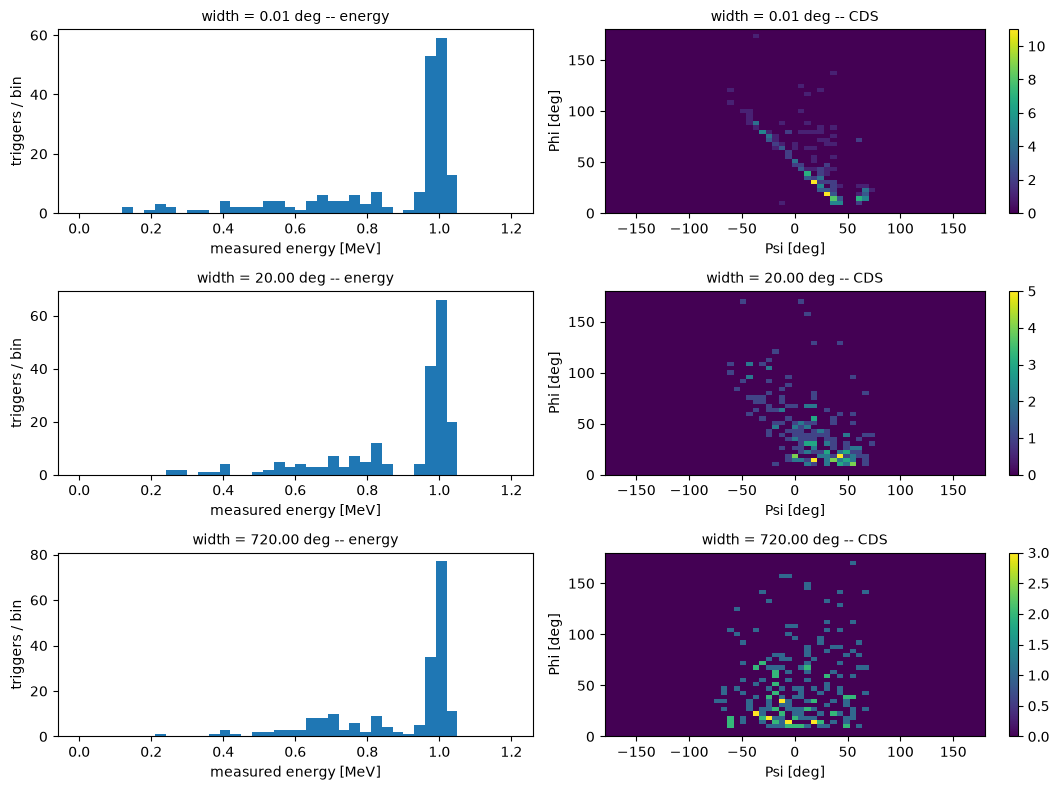

In [7]:
fig, ax = plt.subplots(figsize = (11, 8), nrows = 3, ncols = 2)

for row, (width, result) in enumerate(extended_results.items()):
    plot_energy_and_cds(ax[row][0], ax[row][1], result['events'], f'width = {width:.2f}')

fig.tight_layout()

The measured energy spectra are essentially identical, as they must be: all
three sources have the same 1 MeV line and the same whole-sky flux, so they
launch the same number of photons and deposit energy the same way. `width`
does not touch the spectrum.

The CDS is where the width shows up. The narrow source traces the structured
`Psi`-`Phi` locus of a point source -- the same shape tutorial 02 describes.
As the width grows that locus smears along `Psi`, because `Psi` is essentially
the arrival direction and the arrival directions are now spread over the sky.
By the wide limit it is gone entirely and the CDS is as featureless as an
isotropic background.

That is the practical content of the wide limit: **an extended source wide
enough stops being localisable at all**, and its data are indistinguishable
from a diffuse background -- which is exactly why the isotropic component
exists as a separate source class rather than as `ExtendedSource` with a large
width.